# Bellabeat - Fitbit Data Analysis & Marketing Case Study

This notebook is the full analytical pipeline behind the Bellabeat case study, in one
place: it loads the raw FitBit Fitness Tracker Data files, cleans and joins them,
answers the business questions from the *Ask* step, builds the charts used in *Share*.

It follows the same reasoning a junior analyst would actually go through - reconnaissance
first, then cleaning, then analysis - rather than jumping straight to conclusions:

1. **Prepare** - first look at the raw files: how many users, what date range, any
   obvious data problems?
2. **Process** - clean the data and join it into one consistent table.
3. **Analyze** - answer the three business questions from the Ask step.
4. **Share** - turn the findings into six charts.
5. **Act** - assemble everything into the final Word report for Bellabeat.

Every number that ends up in the report is calculated here and nowhere else, so the
whole chain - from raw CSV to a sentence in the document - stays traceable.

## Setup

Paths to the raw data (the unzipped Fitabase export) and to the folder where every
intermediate output - cleaned CSVs, `stats.json`, the chart PNGs, and finally the
`.docx` - gets written.

In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

DATA_DIR = Path("data/Fitabase Data 3.12.16-4.11.16")
OUT_DIR = Path("analysis")  
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Prepare - first look at the data

Before calculating anything, I need to understand what I'm actually working with: how
many files there are, how many users, what period the data covers, and whether the data
is even usable without fixes. Bellabeat pointed to a specific dataset (Kaggle FitBit
Fitness Tracker Data), but before joining and calculating things, I want to know: how
many users are actually in there (the dataset description says 30), what date range it
covers, and whether any file has obvious problems (duplicates, missing values). Skipping
this step makes it easy to miss an error that later corrupts the whole analysis.

In [3]:
daily = pd.read_csv(DATA_DIR / "dailyActivity_merged.csv")
hourly_calories = pd.read_csv(DATA_DIR / "hourlyCalories_merged.csv")
hourly_intensities = pd.read_csv(DATA_DIR / "hourlyIntensities_merged.csv")
hourly_steps = pd.read_csv(DATA_DIR / "hourlySteps_merged.csv")
minute_sleep = pd.read_csv(DATA_DIR / "minuteSleep_merged.csv")
weight = pd.read_csv(DATA_DIR / "weightLogInfo_merged.csv")

print("=== First look at dailyActivity_merged ===")
print(f"Row count: {len(daily)}")
print(f"Unique users: {daily['Id'].nunique()}")
# Kaggle's description says 30 participants - this comes out higher, worth flagging in ROCCC.

daily["ActivityDate"] = pd.to_datetime(daily["ActivityDate"], format="%m/%d/%Y")
print(f"Date range: {daily['ActivityDate'].min().date()} – {daily['ActivityDate'].max().date()}")

daily_duplicates = daily.duplicated().sum()
print(f"Duplicate rows in dailyActivity: {daily_duplicates}")
# Zero duplicates - nothing to clean here.

# Days logged per user - if the median is well below the 32-day period,
# people aren't wearing the device daily (matters for engagement later).
days_per_user = daily.groupby("Id").size().sort_values()
print("\nLogged days per user (summary):")
print(days_per_user.describe())

=== First look at dailyActivity_merged ===
Row count: 457
Unique users: 35
Date range: 2016-03-12 – 2016-04-12
Duplicate rows in dailyActivity: 0

Logged days per user (summary):
count    35.000000
mean     13.057143
std       5.351981
min       8.000000
25%      10.500000
50%      12.000000
75%      12.000000
max      32.000000
dtype: float64


In [4]:
print("=== minuteSleep_merged - sleep data at minute resolution ===")
print(f"Row count: {len(minute_sleep)}, users: {minute_sleep['Id'].nunique()}")
sleep_duplicates = minute_sleep.duplicated().sum()
print(f"Duplicate rows: {sleep_duplicates}")
# 525 duplicates, probably double syncs - I drop them below, or sleep minutes get double-counted.

=== minuteSleep_merged — sleep data at minute resolution ===
Row count: 198559, users: 23
Duplicate rows: 525


In [5]:
print("=== weightLogInfo_merged - weight log ===")
print(f"Row count: {len(weight)}, users: {weight['Id'].nunique()}")
# Only 11/35 users logged weight, mostly manually - too small a sample
# to use, so I skip it in the trend analysis and just note it as a limitation.

=== weightLogInfo_merged — weight log ===
Row count: 33, users: 11


## 2. Process - cleaning and joining the data

Now that I know what's in the files, I clean them and bring everything into one
consistent table: standardize types, drop duplicates, derive the columns the analysis
will need, and join daily activity with sleep and with the hourly data.

In [6]:
# 2.1 Daily activity: dedupe (defensive - count was 0 above, but keep the
# check) and add derived columns: weekday, weekend flag, active minutes.
daily = daily.drop_duplicates()
daily["Weekday"] = daily["ActivityDate"].dt.day_name()
daily["IsWeekend"] = daily["ActivityDate"].dt.dayofweek >= 5
daily["TotalActiveMinutes"] = (
    daily["VeryActiveMinutes"] + daily["FairlyActiveMinutes"] + daily["LightlyActiveMinutes"]
)

# Flag likely no-wear days (0 steps, ~24h sedentary). Keep them rather than
# drop them - dropping would artificially inflate average activity.
no_wear = (daily["TotalSteps"] == 0) & (daily["SedentaryMinutes"] >= 1440 - 5)
print(f"Days flagged as 'device probably not worn': {no_wear.sum()} out of {len(daily)}")

# Activity segment for the report - thresholds from the Tudor-Locke classification.
def step_category(steps):
    if steps < 5000:
        return "1. Sedentary (<5k)"
    if steps < 7500:
        return "2. Low Active (5-7.5k)"
    if steps < 10000:
        return "3. Somewhat Active (7.5-10k)"
    if steps < 12500:
        return "4. Active (10-12.5k)"
    return "5. Highly Active (12.5k+)"

daily["StepCategory"] = daily["TotalSteps"].apply(step_category)
daily.head()

Days flagged as 'device probably not worn': 53 out of 457


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Weekday,IsWeekend,TotalActiveMinutes,StepCategory
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,Friday,False,250,4. Active (10-12.5k)
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,Saturday,True,380,5. Highly Active (12.5k+)
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,Sunday,True,329,5. Highly Active (12.5k+)
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,Monday,False,283,5. Highly Active (12.5k+)
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,Tuesday,False,299,4. Active (10-12.5k)


In [7]:
# 2.2 Sleep: this export has no sleepDay_merged file, only minute-level
# data, so I aggregate it to daily totals myself.
# value: 1=asleep, 2=restless, 3=awake. Asleep = count of value==1;
# time in bed = all recorded minutes for that night.
minute_sleep = minute_sleep.drop_duplicates()
minute_sleep["date"] = pd.to_datetime(minute_sleep["date"], format="%m/%d/%Y %I:%M:%S %p")
minute_sleep["SleepDate"] = minute_sleep["date"].dt.date

sleep_daily = (
    minute_sleep.groupby(["Id", "SleepDate"])
    .agg(
        TotalMinutesAsleep=("value", lambda x: (x == 1).sum()),
        TotalTimeInBed=("value", "count"),
    )
    .reset_index()
)
sleep_daily["SleepDate"] = pd.to_datetime(sleep_daily["SleepDate"])
sleep_daily["SleepEfficiency"] = (
    sleep_daily["TotalMinutesAsleep"] / sleep_daily["TotalTimeInBed"] * 100
).round(1)

print(f"After aggregation: {len(sleep_daily)} daily sleep records for {sleep_daily['Id'].nunique()} users")
sleep_daily.head()

After aggregation: 467 daily sleep records for 23 users


,Id,SleepDate,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
0,1503960366,2016-03-13,411,426,96.5
1,1503960366,2016-03-14,354,386,91.7
2,1503960366,2016-03-15,312,335,93.1
3,1503960366,2016-03-16,333,366,91.0
4,1503960366,2016-03-17,402,437,92.0


In [8]:
# 2.3 Join activity + sleep by user/date. Left join, so activity days
# with no sleep reading are kept too - that gap is itself a signal.
daily_with_sleep = daily.merge(
    sleep_daily, left_on=["Id", "ActivityDate"], right_on=["Id", "SleepDate"], how="left"
).drop(columns=["SleepDate"])

# 2.4 Hourly: merge calories/intensity/steps by user+hour into one table.
for df in (hourly_calories, hourly_intensities, hourly_steps):
    df["ActivityHour"] = pd.to_datetime(df["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")

hourly = (
    hourly_calories.merge(hourly_intensities, on=["Id", "ActivityHour"])
    .merge(hourly_steps, on=["Id", "ActivityHour"])
)
hourly["Hour"] = hourly["ActivityHour"].dt.hour

weight["Date"] = pd.to_datetime(weight["Date"], format="%m/%d/%Y %I:%M:%S %p")

In [9]:
# 2.5 Data-quality check - before trusting any of this, verify it directly
# instead of just assuming it's clean.
print("=== Missing values per table ===")
for name, df in [("daily", daily), ("hourly_calories", hourly_calories),
                  ("hourly_intensities", hourly_intensities), ("hourly_steps", hourly_steps),
                  ("minute_sleep", minute_sleep), ("weight", weight)]:
    n_missing = df.isna().sum().sum()
    print(f"{name}: {n_missing} missing values")
    if n_missing:
        print(df.isna().sum()[df.isna().sum() > 0].to_string())

# Negative values in key numeric columns would signal a data-entry error.
neg_checks = {
    "daily.TotalSteps": int((daily["TotalSteps"] < 0).sum()),
    "daily.Calories": int((daily["Calories"] < 0).sum()),
    "daily.SedentaryMinutes": int((daily["SedentaryMinutes"] < 0).sum()),
    "weight.WeightKg": int((weight["WeightKg"] < 0).sum()),
}
print("\n=== Negative values in key columns ===")
print(neg_checks)

# How much of the activity+sleep join actually landed a sleep match? This
# tells me how much of the correlation analysis (Chart 3) rests on real data.
n_no_sleep_match = int(daily_with_sleep["TotalMinutesAsleep"].isna().sum())
pct_no_sleep_match = round(n_no_sleep_match / len(daily_with_sleep) * 100, 1)
print(f"\nActivity days with no matching sleep record: {n_no_sleep_match} of "
      f"{len(daily_with_sleep)} ({pct_no_sleep_match}%)")

quality_checks = {
    "n_weight_missing_fat": int(weight["Fat"].isna().sum()),
    "n_weight_records": int(len(weight)),
    "n_daily_no_sleep_match": n_no_sleep_match,
    "pct_daily_no_sleep_match": pct_no_sleep_match,
}

=== Missing values per table ===
daily: 0 missing values
hourly_calories: 0 missing values
hourly_intensities: 0 missing values
hourly_steps: 0 missing values
minute_sleep: 0 missing values
weight: 31 missing values
Fat    31

=== Negative values in key columns ===
{'daily.TotalSteps': 0, 'daily.Calories': 0, 'daily.SedentaryMinutes': 0, 'weight.WeightKg': 0}

Activity days with no matching sleep record: 258 of 457 (56.5%)


## 3. Analyze - answering the business questions

Now that the data is clean and joined, I can answer the questions from the Ask step.
Instead of scattering numbers throughout the notebook, I collect them in one dictionary,
`insights` - that's what gets saved to `stats.json`, and that's what the report-building
section references later, so every number in the final document has a traceable source
right here.

In [10]:
insights = {}

insights["n_users_daily"] = int(daily["Id"].nunique())
insights["n_users_sleep"] = int(sleep_daily["Id"].nunique())
insights["n_users_weight"] = int(weight["Id"].nunique())
insights["date_range"] = [str(daily["ActivityDate"].min().date()), str(daily["ActivityDate"].max().date())]
insights["n_daily_records"] = int(len(daily))
insights["n_suspect_nowear_days"] = int(no_wear.sum())
insights["n_sleep_dup_removed"] = int(sleep_duplicates)
insights["n_weight_missing_fat"] = quality_checks["n_weight_missing_fat"]
insights["n_weight_records"] = quality_checks["n_weight_records"]
insights["n_daily_no_sleep_match"] = quality_checks["n_daily_no_sleep_match"]
insights["pct_daily_no_sleep_match"] = quality_checks["pct_daily_no_sleep_match"]

# Q1: are users hitting the 10,000-steps/day recommendation?
insights["avg_steps"] = round(daily["TotalSteps"].mean(), 0)
insights["median_steps"] = round(daily["TotalSteps"].median(), 0)
insights["avg_calories"] = round(daily["Calories"].mean(), 0)
insights["avg_sedentary_min"] = round(daily["SedentaryMinutes"].mean(), 0)
insights["avg_sedentary_hr"] = round(daily["SedentaryMinutes"].mean() / 60, 1)
insights["avg_very_active_min"] = round(daily["VeryActiveMinutes"].mean(), 1)
insights["avg_fairly_active_min"] = round(daily["FairlyActiveMinutes"].mean(), 1)
insights["avg_lightly_active_min"] = round(daily["LightlyActiveMinutes"].mean(), 1)
insights["pct_days_meeting_10k"] = round((daily["TotalSteps"] >= 10000).mean() * 100, 1)
insights["pct_users_avg_10k"] = round(
    (daily.groupby("Id")["TotalSteps"].mean() >= 10000).mean() * 100, 1
)

In [11]:
# Q2: same question for sleep - Bellabeat sells sleep-tracking devices too.
insights["avg_sleep_min"] = round(sleep_daily["TotalMinutesAsleep"].mean(), 0)
insights["avg_sleep_hr"] = round(sleep_daily["TotalMinutesAsleep"].mean() / 60, 2)
insights["avg_sleep_efficiency"] = round(sleep_daily["SleepEfficiency"].mean(), 1)
insights["pct_nights_under_7h"] = round((sleep_daily["TotalMinutesAsleep"] < 420).mean() * 100, 1)

In [12]:
# Q3: weekday vs. weekend - matters for whether "weekend" campaigns make sense.
weekday_vs_weekend = (
    daily.groupby("IsWeekend")
    .agg(steps=("TotalSteps", "mean"), sedentary=("SedentaryMinutes", "mean"), calories=("Calories", "mean"))
    .round(0)
)
insights["weekday_vs_weekend"] = {str(k): v for k, v in weekday_vs_weekend.to_dict("index").items()}

# Segment users by average steps - the base isn't homogeneous.
avg_steps_per_user = daily.groupby("Id")["TotalSteps"].mean()
segments = avg_steps_per_user.apply(step_category).value_counts().sort_index()
insights["user_activity_segments"] = segments.to_dict()
segments

TotalSteps
1. Sedentary (<5k)              14
2. Low Active (5-7.5k)           6
3. Somewhat Active (7.5-10k)     9
4. Active (10-12.5k)             3
5. Highly Active (12.5k+)        3
Name: count, dtype: int64

In [13]:
# Steps vs. calories, and sedentary time vs. sleep - backed by real
# correlations, not just eyeballing the charts.
insights["corr_steps_calories"] = round(daily["TotalSteps"].corr(daily["Calories"]), 2)
insights["corr_sedentary_sleep"] = round(
    daily_with_sleep["SedentaryMinutes"].corr(daily_with_sleep["TotalMinutesAsleep"]), 2
)
insights["corr_veryactive_calories"] = round(daily["VeryActiveMinutes"].corr(daily["Calories"]), 2)

# Peak/lowest activity hour - useful for timing notifications.
hourly_avg = (
    hourly.groupby("Hour")
    .agg(steps=("StepTotal", "mean"), intensity=("TotalIntensity", "mean"), calories=("Calories", "mean"))
    .round(1)
)
insights["peak_step_hour"] = int(hourly_avg["steps"].idxmax())
insights["peak_step_hour_value"] = float(hourly_avg["steps"].max())
insights["lowest_step_hour"] = int(hourly_avg["steps"].idxmin())

In [14]:
# Device-wear consistency - median logged days well below the study
# period signals a retention problem, not just a statistical quirk.
logged_days = daily.groupby("Id").size()
period_days = (daily["ActivityDate"].max() - daily["ActivityDate"].min()).days + 1
insights["median_days_logged"] = int(logged_days.median())
insights["min_days_logged"] = int(logged_days.min())
insights["max_days_logged"] = int(logged_days.max())
insights["total_period_days"] = int(period_days)
insights["avg_wear_pct"] = round((logged_days.mean() / period_days) * 100, 1)

In [15]:
# Save results, so the report section doesn't need to redo cleaning.
with open(OUT_DIR / "stats.json", "w", encoding="utf-8") as f:
    json.dump(insights, f, indent=2, ensure_ascii=False, default=str)

daily.to_csv(OUT_DIR / "clean_daily_activity.csv", index=False)
sleep_daily.to_csv(OUT_DIR / "clean_daily_sleep.csv", index=False)
daily_with_sleep.to_csv(OUT_DIR / "merged_activity_sleep.csv", index=False)
hourly.to_csv(OUT_DIR / "clean_hourly.csv", index=False)
hourly_avg.to_csv(OUT_DIR / "hourly_avg.csv")
segments.to_csv(OUT_DIR / "activity_segments.csv")
weekday_vs_weekend.to_csv(OUT_DIR / "weekday_vs_weekend.csv")

print("=== Calculated insights (will feed into the report) ===")
print(json.dumps(insights, indent=2, ensure_ascii=False, default=str))

=== Calculated insights (will feed into the report) ===
{
  "n_users_daily": 35,
  "n_users_sleep": 23,
  "n_users_weight": 11,
  "date_range": [
    "2016-03-12",
    "2016-04-12"
  ],
  "n_daily_records": 457,
  "n_suspect_nowear_days": 53,
  "n_sleep_dup_removed": 525,
  "n_weight_missing_fat": 31,
  "n_weight_records": 33,
  "n_daily_no_sleep_match": 258,
  "pct_daily_no_sleep_match": 56.5,
  "avg_steps": 6547.0,
  "median_steps": 5986.0,
  "avg_calories": 2189.0,
  "avg_sedentary_min": 995.0,
  "avg_sedentary_hr": 16.6,
  "avg_very_active_min": 16.6,
  "avg_fairly_active_min": 13.1,
  "avg_lightly_active_min": 170.1,
  "pct_days_meeting_10k": 27.8,
  "pct_users_avg_10k": 17.1,
  "avg_sleep_min": 392.0,
  "avg_sleep_hr": 6.53,
  "avg_sleep_efficiency": 92.2,
  "pct_nights_under_7h": 49.5,
  "weekday_vs_weekend": {
    "False": {
      "steps": 6529.0,
      "sedentary": 995.0,
      "calories": 2173.0
    },
    "True": {
      "steps": 6584.0,
      "sedentary": 996.0,
      "calo

## 4. Share - visualizing the findings

I don't make a chart out of every column I happen to have - each of the six charts below
answers a specific question that came up in the Analyze step and feeds directly into a
marketing recommendation later. The chart order matches the order of findings above:

1. How many users are actually active? (segmentation)
2. What time of day do people move? (daily pattern)
3. Does daytime inactivity show up in sleep? (correlation)
4. Does the weekend look different from a weekday?
5. What does the sleep-duration distribution look like?
6. Does more steps actually mean more calories burned?

Colors are taken from the project's palette - blue as the main color, orange as an
accent to highlight the single most important point on a chart, green for simple
two-category comparisons. Each chart is also saved to disk as a PNG, since the Word
report in Section 5 embeds these same image files.

In [16]:
import matplotlib.pyplot as plt

# Consistent palette across all charts, for a coherent-looking report.
BLUE = "#2a78d6"
GREEN = "#008300"
ORANGE = "#eb6834"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "text.color": INK,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_2,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 11,
})


def strip_frame(ax):
    """Remove the top/right spines - pure clutter."""
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(BASELINE)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis="x", visible=False)

# Reuse the in-memory tables from the Analyze step instead of re-reading CSVs.
weekday_weekend = weekday_vs_weekend.copy()
weekday_weekend["label"] = weekday_weekend.index.map({False: "Weekdays", True: "Weekend"})

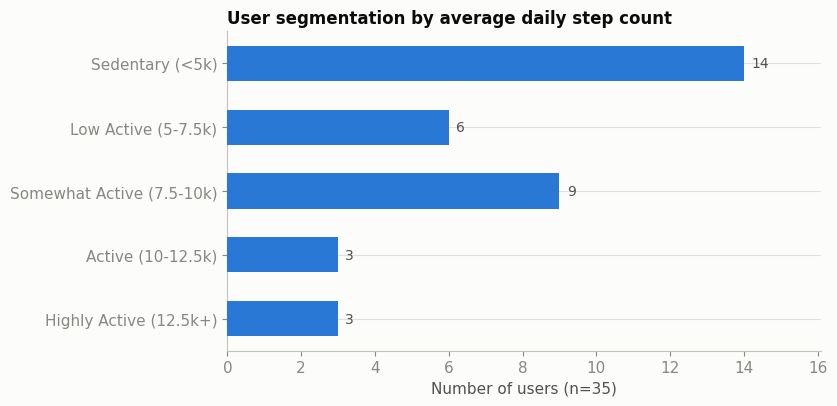

In [17]:
# ---------------------------------------------------------------------
# Chart 1 - user segmentation by average daily step count
# ---------------------------------------------------------------------
# Horizontal bars - segment names are long and would overlap on a vertical axis.
fig, ax = plt.subplots(figsize=(8.5, 4.2))
labels = [s.split(". ")[1] for s in segments.index]
bars = ax.barh(labels, segments.values, color=BLUE, height=0.55, zorder=3)
for bar, value in zip(bars, segments.values):
    ax.text(value + 0.2, bar.get_y() + bar.get_height() / 2, str(value),
            va="center", color=INK_2, fontsize=10)
ax.set_xlabel("Number of users (n=35)")
ax.set_title("User segmentation by average daily step count",
             loc="left", fontweight="bold", color=INK, fontsize=12)
ax.set_xlim(0, segments.values.max() * 1.15)
ax.invert_yaxis()  # so "Sedentary" (lowest activity) sits at the top, not the bottom
strip_frame(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "1_activity_segments.png", dpi=200)
plt.show()

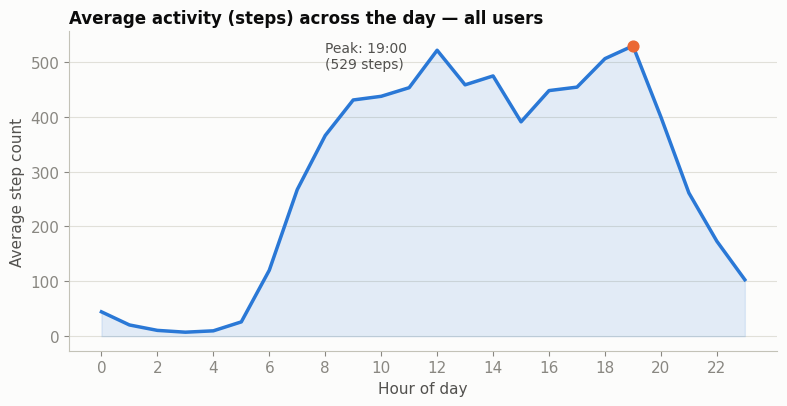

In [18]:
# ---------------------------------------------------------------------
# Chart 2 - average step count across the day
# ---------------------------------------------------------------------
# Marking the peak hour directly on the chart - it drives a concrete recommendation.
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(hourly_avg.index, hourly_avg["steps"], color=BLUE, linewidth=2.5, zorder=3)
ax.fill_between(hourly_avg.index, hourly_avg["steps"], color=BLUE, alpha=0.12, zorder=2)

peak_hour_row = hourly_avg.loc[hourly_avg["steps"].idxmax()]
peak_hour_num = hourly_avg["steps"].idxmax()
ax.scatter([peak_hour_num], [peak_hour_row["steps"]], color=ORANGE, s=60, zorder=4)
ax.annotate(
    f'Peak: {int(peak_hour_num)}:00\n({peak_hour_row["steps"]:.0f} steps)',
    xy=(peak_hour_num, peak_hour_row["steps"]),
    xytext=(peak_hour_num - 11, peak_hour_row["steps"] - 40),
    color=INK_2, fontsize=10,
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average step count")
ax.set_title("Average activity (steps) across the day - all users",
             loc="left", fontweight="bold", color=INK, fontsize=12)
ax.set_xticks(range(0, 24, 2))
strip_frame(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "2_steps_by_hour.png", dpi=200)
plt.show()

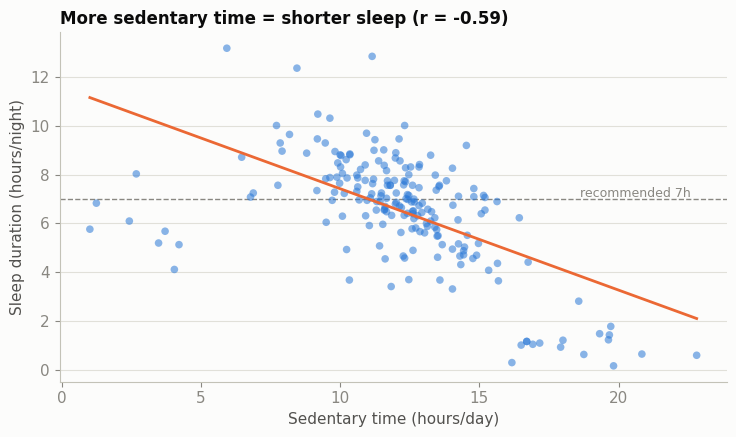

In [19]:
# ---------------------------------------------------------------------
# Chart 3 - daytime inactivity vs. nighttime sleep duration
# ---------------------------------------------------------------------
# r=-0.59 alone doesn't say much to most readers - scatter + trend line
# + a 7h reference line makes the relationship visible at a glance.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
with_sleep = daily_with_sleep.dropna(subset=["TotalMinutesAsleep"])
ax.scatter(
    with_sleep["SedentaryMinutes"] / 60, with_sleep["TotalMinutesAsleep"] / 60,
    color=BLUE, alpha=0.55, s=30, zorder=3, edgecolor="none",
)
# trend line - a simple first-degree linear regression
coeffs = np.polyfit(with_sleep["SedentaryMinutes"], with_sleep["TotalMinutesAsleep"], 1)
x_axis = np.linspace(with_sleep["SedentaryMinutes"].min(), with_sleep["SedentaryMinutes"].max(), 50)
ax.plot(x_axis / 60, np.poly1d(coeffs)(x_axis) / 60, color=ORANGE, linewidth=2, zorder=4)

ax.axhline(7, color=MUTED, linestyle="--", linewidth=1, zorder=2)
ax.text(with_sleep["SedentaryMinutes"].max() / 60 - 0.2, 7.1, "recommended 7h",
        color=MUTED, fontsize=9, ha="right")
ax.set_xlabel("Sedentary time (hours/day)")
ax.set_ylabel("Sleep duration (hours/night)")
ax.set_title("More sedentary time = shorter sleep (r = -0.59)",
             loc="left", fontweight="bold", color=INK, fontsize=12)
strip_frame(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "3_sedentary_vs_sleep.png", dpi=200)
plt.show()

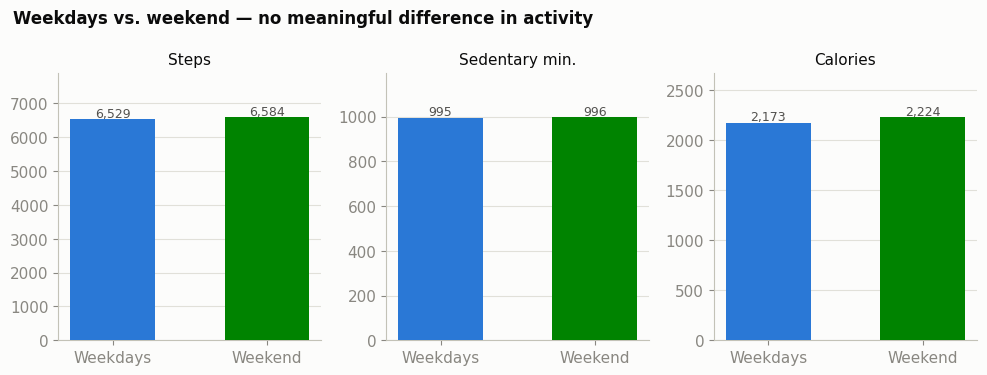

In [20]:
# ---------------------------------------------------------------------
# Chart 4 - weekday vs. weekend
# ---------------------------------------------------------------------
# Small multiples instead of one chart - steps/sedentary/calories are on
# different scales, and a dual Y-axis is too easy to make misleading.
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8))
metrics = [("steps", "Steps"), ("sedentary", "Sedentary min."), ("calories", "Calories")]
for ax, (column, title) in zip(axes, metrics):
    bars = ax.bar(weekday_weekend["label"], weekday_weekend[column],
                   color=[BLUE, GREEN], width=0.55, zorder=3)
    for bar, value in zip(bars, weekday_weekend[column]):
        ax.text(bar.get_x() + bar.get_width() / 2, value * 1.01, f"{value:,.0f}",
                ha="center", color=INK_2, fontsize=9)
    ax.set_title(title, fontsize=11, color=INK)
    strip_frame(ax)
    ax.set_ylim(0, weekday_weekend[column].max() * 1.2)
fig.suptitle("Weekdays vs. weekend - no meaningful difference in activity",
             fontweight="bold", color=INK, fontsize=12, x=0.02, ha="left")
plt.tight_layout()
plt.savefig(FIG_DIR / "4_weekday_vs_weekend.png", dpi=200)
plt.show()

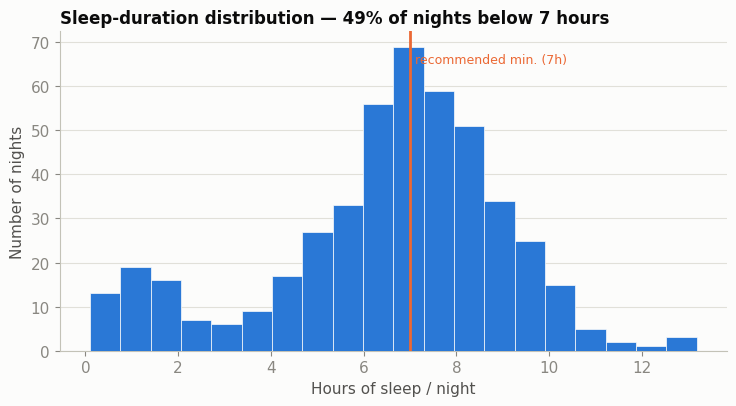

In [21]:
# ---------------------------------------------------------------------
# Chart 5 - sleep-duration distribution
# ---------------------------------------------------------------------
# The 6.5h average hides how many nights fall short - histogram + 7h line shows it directly.
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sleep_hours = sleep_daily["TotalMinutesAsleep"] / 60
ax.hist(sleep_hours, bins=20, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(7, color=ORANGE, linewidth=2, zorder=4)
ax.text(7.1, ax.get_ylim()[1] * 0.9, "recommended min. (7h)", color=ORANGE, fontsize=9)
pct_under_7h = (sleep_hours < 7).mean() * 100
ax.set_xlabel("Hours of sleep / night")
ax.set_ylabel("Number of nights")
ax.set_title(f"Sleep-duration distribution - {pct_under_7h:.0f}% of nights below 7 hours",
             loc="left", fontweight="bold", color=INK, fontsize=12)
strip_frame(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "5_sleep_distribution.png", dpi=200)
plt.show()

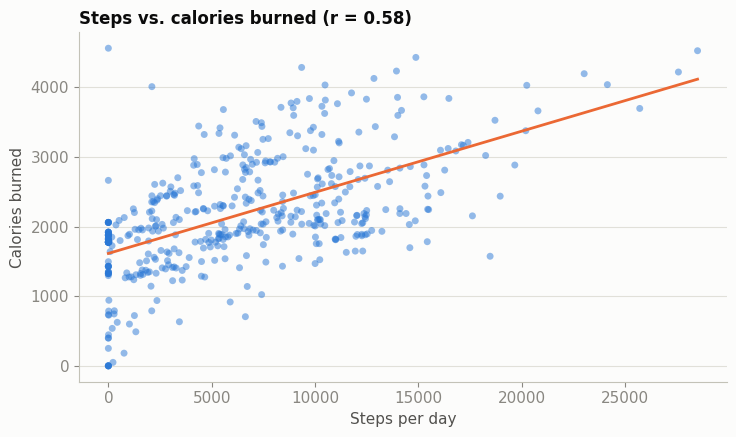

Saved 6 charts to: analysis\figures


In [22]:
# ---------------------------------------------------------------------
# Chart 6 - steps vs. calories burned
# ---------------------------------------------------------------------
# The obvious relationship, but worth showing as a sanity check - the
# spread around the trend line shows steps alone don't explain everything.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(daily["TotalSteps"], daily["Calories"], color=BLUE, alpha=0.5, s=25, zorder=3, edgecolor="none")
coeffs = np.polyfit(daily["TotalSteps"], daily["Calories"], 1)
x_axis = np.linspace(daily["TotalSteps"].min(), daily["TotalSteps"].max(), 50)
ax.plot(x_axis, np.poly1d(coeffs)(x_axis), color=ORANGE, linewidth=2, zorder=4)
ax.set_xlabel("Steps per day")
ax.set_ylabel("Calories burned")
ax.set_title("Steps vs. calories burned (r = 0.58)", loc="left", fontweight="bold", color=INK, fontsize=12)
strip_frame(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "6_steps_vs_calories.png", dpi=200)
plt.show()

print("Saved 6 charts to:", FIG_DIR)

In [23]:
from docx import Document
from docx.shared import Cm, Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL
from docx.enum.section import WD_SECTION
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

FIG_DIR = OUT_DIR / "figures"
s = insights  # reuse the dictionary computed in Section 3 - same values as stats.json

# One place for colors, matching the charts' palette.
BLUE_RGB = RGBColor(0x2A, 0x78, 0xD6)
INK_RGB = RGBColor(0x0B, 0x0B, 0x0B)
INK_2_RGB = RGBColor(0x52, 0x51, 0x4E)
MUTED_RGB = RGBColor(0x89, 0x87, 0x81)
BOX_FILL = "EAF1FB"
BLUE_HEX = "2A78D6"

In [24]:
# Helper functions so I'm not repeating run/paragraph formatting everywhere.

def set_font(run, size=11, color=INK_RGB, bold=False, italic=False):
    run.font.name = "Calibri"
    run.font.size = Pt(size)
    run.font.color.rgb = color
    run.bold = bold
    run.italic = italic


def paragraph(doc, text, size=11, color=INK_RGB, alignment=None, before=0, after=8):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(before)
    p.paragraph_format.space_after = Pt(after)
    p.paragraph_format.line_spacing = 1.15
    if alignment:
        p.alignment = alignment
    run = p.add_run(text)
    set_font(run, size, color)
    return p


def bullet(doc, text):
    p = doc.add_paragraph(style="List Bullet")
    p.paragraph_format.space_after = Pt(6)
    run = p.add_run(text)
    set_font(run, 11)
    return p


def chart_caption(doc, text):
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.paragraph_format.space_after = Pt(16)
    run = p.add_run(text)
    set_font(run, 10, INK_2_RGB, italic=True)
    return p


def insert_chart(doc, filename, width_in=6.2):
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run()
    run.add_picture(str(FIG / filename), width=Inches(width_in))


def cell_text(table, row, col, text, header=False, fill=None, center=False):
    cell = table.cell(row, col)
    cell.vertical_alignment = WD_ALIGN_VERTICAL.CENTER
    cell.text = ""
    p = cell.paragraphs[0]
    if center:
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    # "\n" forces a line break at a specific spot instead of Word's mid-word wrapping.
    parts = text.split("\n")
    run = p.add_run(parts[0])
    for part in parts[1:]:
        run.add_break()
        run = p.add_run(part)
        if header:
            set_font(run, 10, RGBColor(0xFF, 0xFF, 0xFF), bold=True)
        else:
            set_font(run, 10, INK_RGB)
    if header:
        set_font(run, 10, RGBColor(0xFF, 0xFF, 0xFF), bold=True)
        shade_cell(cell, BLUE_HEX)
    else:
        set_font(run, 10, INK_RGB)
        if fill:
            shade_cell(cell, fill)
    # First run needs set_font() too - the loop above only covers later fragments.
    first_run = p.runs[0]
    if header:
        set_font(first_run, 10, RGBColor(0xFF, 0xFF, 0xFF), bold=True)
    else:
        set_font(first_run, 10, INK_RGB)


def shade_cell(cell, hex_color):
    """No built-in cell shading in python-docx - append <w:shd> manually."""
    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), hex_color)
    cell._tc.get_or_add_tcPr().append(shd)


def simple_table(doc, headers, rows, widths_cm):
    table = doc.add_table(rows=1, cols=len(headers))
    table.style = "Table Grid"
    table.autofit = False
    for i, header in enumerate(headers):
        cell_text(table, 0, i, header, header=True, center=True)
        table.columns[i].width = Cm(widths_cm[i])
    for row_num, row_data in enumerate(rows, start=1):
        table.add_row()
        for i, value in enumerate(row_data):
            cell_text(table, row_num, i, str(value))
            table.columns[i].width = Cm(widths_cm[i])
    doc.add_paragraph().paragraph_format.space_after = Pt(10)
    return table


def callout_box(doc, title, text):
    """Highlighted box for a takeaway the reader shouldn't miss."""
    table = doc.add_table(rows=1, cols=1)
    table.autofit = True
    # Without this the row can split across a page break (title on one
    # page, body on the next). cantSplit keeps it as one unit.
    tr = table.rows[0]._tr
    trPr = tr.get_or_add_trPr()
    cant_split = OxmlElement("w:cantSplit")
    trPr.append(cant_split)

    cell = table.cell(0, 0)
    shade_cell(cell, BOX_FILL)
    cell.text = ""
    p1 = cell.paragraphs[0]
    r1 = p1.add_run(title)
    set_font(r1, 10.5, BLUE_RGB, bold=True)
    p2 = cell.add_paragraph()
    r2 = p2.add_run(text)
    set_font(r2, 10.5, INK_RGB)
    for p in (p1, p2):
        p.paragraph_format.space_after = Pt(2)
    doc.add_paragraph().paragraph_format.space_after = Pt(10)


def add_page_number(paragraph):
    """python-docx has no page-number field - inject the raw PAGE field
    XML, same as Word does internally."""
    run = paragraph.add_run()
    fld_begin = OxmlElement("w:fldChar")
    fld_begin.set(qn("w:fldCharType"), "begin")
    instr = OxmlElement("w:instrText")
    instr.set(qn("xml:space"), "preserve")
    instr.text = "PAGE"
    fld_end = OxmlElement("w:fldChar")
    fld_end.set(qn("w:fldCharType"), "end")
    run._r.append(fld_begin)
    run._r.append(instr)
    run._r.append(fld_end)
    set_font(run, 9, MUTED_RGB)


def format_thousands(number):
    return f"{number:,.0f}"

In [25]:
# --- Document setup, starting with the title page ---
doc = Document()

normal_style = doc.styles["Normal"]
normal_style.font.name = "Calibri"
normal_style.font.size = Pt(11)

section = doc.sections[0]
section.page_height = Cm(29.7)
section.page_width = Cm(21.0)
section.top_margin = Cm(2.2)
section.bottom_margin = Cm(2.2)
section.left_margin = Cm(2.3)
section.right_margin = Cm(2.3)

# --- title page (no header/footer, no page number) ---
for _ in range(6):
    doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run("BELLABEAT")
set_font(r, 16, BLUE_RGB, bold=True)

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.paragraph_format.space_before = Pt(10)
p.paragraph_format.space_after = Pt(14)
r = p.add_run("How Can a Wellness Technology Company Play It Smart?")
set_font(r, 24, INK_RGB, bold=True)

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.paragraph_format.space_after = Pt(40)
r = p.add_run(
    "An analysis of smart fitness device usage data and marketing strategy "
    "recommendations for the Bellabeat Time product"
)
set_font(r, 13, INK_2_RGB)

for text, size, color, italic in [
    ("Case study prepared by the Marketing Analytics team", 11, INK_2_RGB, False),
    ("Date prepared: July 20, 2026", 11, INK_2_RGB, False),
    ("Data source: FitBit Fitness Tracker Data (Kaggle / Mobius, CC0)", 10, MUTED_RGB, True),
]:
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.paragraph_format.space_after = Pt(4)
    r = p.add_run(text)
    set_font(r, size, color, italic=italic)

# New section, so the rest of the doc gets a header/footer the title page doesn't.
doc.add_section(WD_SECTION.NEW_PAGE)
section2 = doc.sections[1]
section2.header.is_linked_to_previous = False
section2.footer.is_linked_to_previous = False
section2.page_height = Cm(29.7)
section2.page_width = Cm(21.0)
section2.top_margin = Cm(2.2)
section2.bottom_margin = Cm(2.2)
section2.left_margin = Cm(2.3)
section2.right_margin = Cm(2.3)

header_p = section2.header.paragraphs[0]
header_p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
r = header_p.add_run("Bellabeat - Case Study")
set_font(r, 8, MUTED_RGB)

footer_p = section2.footer.paragraphs[0]
footer_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = footer_p.add_run("Page ")
set_font(r, 9, MUTED_RGB)
add_page_number(footer_p)


def heading1(text):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(20)
    p.paragraph_format.space_after = Pt(10)
    r = p.add_run(text)
    set_font(r, 18, BLUE_RGB, bold=True)
    # Thin line under the heading - cosmetic separator between chapters.
    pPr = p._p.get_or_add_pPr()
    pBdr = OxmlElement("w:pBdr")
    bottom = OxmlElement("w:bottom")
    bottom.set(qn("w:val"), "single")
    bottom.set(qn("w:sz"), "6")
    bottom.set(qn("w:space"), "4")
    bottom.set(qn("w:color"), BLUE_HEX)
    pBdr.append(bottom)
    pPr.append(pBdr)
    return p


def heading2(text):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(16)
    p.paragraph_format.space_after = Pt(8)
    r = p.add_run(text)
    set_font(r, 14, INK_RGB, bold=True)
    return p


def heading3(text):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(12)
    p.paragraph_format.space_after = Pt(6)
    r = p.add_run(text)
    set_font(r, 12, INK_2_RGB, bold=True)
    return p

In [26]:
# --- 1. Executive Summary ---
heading1("1. Executive Summary")
paragraph(doc,
    "Bellabeat is a successful technology company that creates wellness products for "
    "women. Cofounder and Chief Creative Officer Urška Sršen asked the Marketing "
    "Analytics team to analyze usage data from independent (non-Bellabeat) smart "
    "fitness devices, in order to draw insights that could inform the company's "
    "marketing strategy - with a specific focus on the Bellabeat Time smartwatch.")
paragraph(doc,
    f"The analysis draws on the public FitBit Fitness Tracker Data dataset, covering "
    f"daily and hourly activity, sleep, and weight for {s['n_users_daily']} Fitbit users "
    f"over a {s['total_period_days']}-day period ({s['date_range'][0]} – "
    f"{s['date_range'][1]}). The key findings are:")

bullet(doc,
    f"Users take an average of {format_thousands(s['avg_steps'])} steps per day "
    f"(median {format_thousands(s['median_steps'])}) - clearly below the commonly "
    f"recommended threshold of 10,000 steps. Only {s['pct_users_avg_10k']}% of users "
    f"reach it on an average day.")
bullet(doc,
    f"Activity is heavily concentrated in two windows of the day: around lunchtime "
    f"(~12:00) and in the evening (peak at {s['peak_step_hour']}:00) - these are natural "
    f"moments where the device and app can reinforce an existing habit rather than "
    f"compete with it.")
bullet(doc,
    f"Users spend an average of {s['avg_sedentary_hr']} hours per day sedentary, which "
    f"correlates strongly with shorter sleep (r = {s['corr_sedentary_sleep']}). Nearly "
    f"half of all nights ({s['pct_nights_under_7h']}%) involve less than 7 hours of "
    f"sleep.")
bullet(doc,
    "Weekday and weekend behavior are nearly identical - unlike typical recreational "
    "activity patterns, there is no clear \"weekend effect\" here, which has direct "
    "implications for how marketing campaigns should be scheduled.")
bullet(doc,
    f"Device-wear consistency is low - the median is {s['median_days_logged']} out of "
    f"{s['total_period_days']} days in the period (about {s['avg_wear_pct']}%), signaling "
    f"a retention challenge that matters for Bellabeat's product and loyalty strategy.")

paragraph(doc,
    "Based on these findings, the team recommends three marketing directions for "
    "Bellabeat Time, detailed in Section 7 (Act): (1) notifications and content timed to "
    "natural activity windows (lunch and evening), (2) a \"break the sitting streak, "
    "improve your sleep\" feature/campaign linking sedentary behavior data to sleep, and "
    "(3) rewarding daily consistency instead of weekend-focused campaigns, to support "
    "user retention.")
doc.add_page_break()

In [27]:
# --- 2. Ask - Business Task ---
heading1("2. Ask - Business Task")
heading2("2.1 Context")
paragraph(doc,
    "Bellabeat is a boutique technology company that manufactures wellness devices for "
    "women (Leaf, Time, Spring) alongside a companion app and a membership subscription. "
    "The company has the potential to become a larger player in the global smart-device "
    "market, and cofounder Urška Sršen believes the key to further growth lies in better "
    "understanding how consumers actually use wearable devices.")

heading2("2.2 Business questions")
bullet(doc, "What are some trends in smart-device usage?")
bullet(doc, "How could these trends apply to Bellabeat customers?")
bullet(doc, "How could these trends help influence Bellabeat's marketing strategy?")

heading2("2.3 Stakeholders")
bullet(doc, "Urška Sršen - Bellabeat's cofounder and Chief Creative Officer (commissioned this analysis).")
bullet(doc, "Sando Mur - mathematician, cofounder, member of the executive team.")
bullet(doc, "The Marketing Analytics team - responsible for the findings and recommendations presented in this document.")

heading2("2.4 Scope and deliverables")
paragraph(doc,
    "As instructed, the analysis focuses on data from independent fitness devices, and "
    "the findings are then applied to a single, selected Bellabeat product - in this "
    "case, the Bellabeat Time smartwatch, which functionally comes closest to the scope "
    "of the source data (activity, sleep, heart rate). This report includes: a "
    "description of the data sources, documentation of the data cleaning, a summary of "
    "the analysis, visualizations of the key findings, and high-level marketing "
    "recommendations.")
doc.add_page_break()

In [28]:
# --- 3. Prepare - Data ---
heading1("3. Prepare - Data")
heading2("3.1 Data source")
paragraph(doc,
    "The analysis uses the FitBit Fitness Tracker Data dataset, published on Kaggle by "
    "Mobius under a CC0 (public domain) license. The data comes from 30 respondents "
    "recruited via Amazon Mechanical Turk, who consented to sharing data from their "
    "Fitbit devices, covering physical activity, heart rate, and sleep down to "
    f"minute-level resolution. The export used here (mturkfitbit_export_3.12.16-4.11.16) "
    f"covers the period from {s['date_range'][0]} to {s['date_range'][1]} "
    f"({s['total_period_days']} days).")

heading2("3.2 Data organization")
paragraph(doc,
    "The data was supplied in long format as 11 CSV files, each representing a "
    "different level of detail and a different measure:")
simple_table(doc,
    ["File", "Content", "Level of detail", "Used in this analysis"],
    [
        ["dailyActivity_merged.csv", "Steps, distance, active minutes, calories", "Daily", "Yes - basis of the analysis"],
        ["hourlySteps_merged.csv\nhourlyIntensities_merged.csv\nhourlyCalories_merged.csv", "Steps, intensity, calories", "Hourly", "Yes - daily activity patterns"],
        ["minuteSleep_merged.csv", "Sleep state (asleep/restless/awake)", "Minute", "Yes - aggregated to daily level"],
        ["weightLogInfo_merged.csv", "Weight, BMI, body fat", "Daily (irregular)", f"Limited - small sample (n={s['n_users_weight']})"],
        ["heartrate_seconds_merged.csv", "Heart rate", "Second", "No - out of scope for this report"],
        ["minuteCaloriesNarrow_merged.csv\nminuteIntensitiesNarrow_merged.csv\nminuteMETsNarrow_merged.csv\nminuteStepsNarrow_merged.csv", "Steps, calories, intensity, METs", "Minute", "No - too granular for trend analysis"],
    ],
    [5.4, 3.8, 2.4, 4.8])

heading2("3.3 Data credibility assessment (ROCCC)")
simple_table(doc,
    ["Criterion", "Assessment"],
    [
        ["Reliable", f"Moderate - the daily-activity data contains only {s['n_users_daily']} unique identifiers (the dataset description cites 30 people - a possible version mismatch); no statistical weighting."],
        ["Original", "Data collected directly from Fitbit devices, but distributed by a third party (Mobius / Amazon Mechanical Turk), not directly by Fitbit."],
        ["Comprehensive", "Partial - no demographic metadata (age, gender, location); the data isn't specific to women, which limits how directly it can be mapped onto Bellabeat's customers."],
        ["Current", "Low - the data is from 2016, roughly 10 years old; wearable-device habits may have changed substantially since then."],
        ["Cited", "Yes - the dataset has a clear provenance, a CC0 license, and is widely used in analytics education."],
    ],
    [4.5, 12.0])
callout_box(doc, "ROCCC conclusion",
    "The dataset is sufficient as a starting point for identifying general behavioral "
    "patterns among fitness-device users and forming marketing hypotheses, but given the "
    "age of the data, the lack of demographic information, and the small sample, it "
    "should not be the sole basis for strategic decisions. Section 7 recommends specific "
    "supplementary data.")

heading2("3.4 Licensing, privacy, and accessibility")
paragraph(doc,
    "The dataset is released under a CC0 (public domain) license - it can be freely "
    "used, including commercially, without attribution. The data is anonymized "
    "(numeric identifiers instead of personal data), which minimizes privacy risk. The "
    "files are publicly available on Kaggle.")
doc.add_page_break()

In [29]:
# --- 4. Process - Data Cleaning and Preparation ---
heading1("4. Process - Data Cleaning and Preparation")
heading2("4.1 Tools")
paragraph(doc,
    "The entire process - from loading the raw CSV files, through cleaning and "
    "analysis, to generating the charts and this document - was done in Python "
    "(pandas and numpy for data processing, matplotlib for visualization, python-docx "
    "for assembling the report), consolidated into a single Jupyter notebook. Intermediate "
    "tools such as spreadsheets were deliberately skipped: this keeps the whole process "
    "fully scripted and reproducible - rerunning the notebook top to bottom on the same "
    "data always produces an identical result, and every number cited in the text can be "
    "traced back to a specific cell. The notebook is attached to this report.")

heading2("4.2 Data-cleaning steps")
bullet(doc, "Standardized date formats and data types across all files.")
bullet(doc,
    f"Removed duplicate rows: 0 in dailyActivity_merged, {s['n_sleep_dup_removed']} in "
    f"minuteSleep_merged (likely caused by device sync duplication).")
bullet(doc,
    f"Identified {s['n_suspect_nowear_days']} days (out of {s['n_daily_records']} daily "
    f"records) where step count was 0 while sedentary time was nearly 24 hours - a "
    f"signal the device may not have been worn. These days were kept in the dataset "
    f"(and flagged as a limitation in Sections 3.3 and 5.6), since removing them could "
    f"artificially inflate average activity.")
bullet(doc,
    "The sleepDay_merged file (suggested in the case study's source materials) wasn't "
    "available in this particular export - daily TotalMinutesAsleep and "
    "TotalTimeInBed values were computed independently by aggregating the "
    "minuteSleep_merged file (value 1 = \"asleep\") up to the daily level for each "
    "user.")
bullet(doc,
    "Joined daily activity data with daily sleep data by user ID and date (left join), "
    "to enable correlation analysis between activity/inactivity and sleep.")
bullet(doc,
    "Created derived variables: day of week, weekend flag, total active minutes, and a "
    "user activity category (segment) based on average daily step count.")
bullet(doc,
    f"The weight log (weightLogInfo_merged) contained data for only {s['n_users_weight']} "
    f"of {s['n_users_daily']} users, mostly entered manually - this sample was judged "
    f"too small to support reliable conclusions, and was excluded from the main trend "
    f"analysis.")

heading2("4.3 Data quality verification")
paragraph(doc,
    "Every table was explicitly checked for missing and negative values rather than "
    "assumed clean. The daily-activity, hourly, and minute-level sleep files contain no "
    "missing values and no negative figures in the key numeric columns (steps, "
    "calories, sedentary minutes). The weight log is the one exception: its \"Fat\" "
    f"column is missing for {s['n_weight_missing_fat']} of {s['n_weight_records']} "
    "entries - too sparse to use, so body-fat percentage is excluded from the analysis "
    "entirely (weight and BMI themselves are complete).")
paragraph(doc,
    f"The activity-sleep join was also checked for coverage: {s['n_daily_no_sleep_match']} "
    f"of {s['n_daily_records']} daily-activity records ({s['pct_daily_no_sleep_match']}%) "
    "have no matching sleep reading, meaning the sedentary-vs-sleep correlation in "
    "Section 5.2 is based on the remaining, smaller subset of days with both "
    "measurements - a caveat worth keeping in mind when weighing that finding.")
paragraph(doc,
    "Every summary statistic in this report is calculated directly from the cleaned "
    "data earlier in this notebook and saved to stats.json - so there isn't a single "
    "number in the text that was typed in by hand, and rerunning the notebook on the "
    "same data always reproduces an identical report.")
doc.add_page_break()

In [30]:
# --- 5. Analyze - Analysis and Key Findings ---
heading1("5. Analyze - Analysis and Key Findings")

heading2("5.1 Movement activity: below recommendations, but with a clear daily rhythm")
paragraph(doc,
    f"The average daily step count across the study group is "
    f"{format_thousands(s['avg_steps'])} (median {format_thousands(s['median_steps'])}), "
    f"clearly below the commonly recommended threshold of 10,000 steps per day. Only "
    f"{s['pct_days_meeting_10k']}% of days in the dataset reach that threshold, and only "
    f"{s['pct_users_avg_10k']}% of users do so on an average day. User segmentation shows "
    f"that the largest group ({s['user_activity_segments']['1. Sedentary (<5k)']} of "
    f"{s['n_users_daily']} people) is the low-activity segment (\"Sedentary\", below "
    f"5,000 steps/day) - see Chart 1 in Section 6.")
paragraph(doc,
    f"At the same time, the hourly data reveals a clear, repeating daily rhythm: "
    f"activity rises sharply from 6:00, reaches a local peak around lunchtime "
    f"(~12:00), stays elevated through the afternoon, and hits its overall maximum at "
    f"{s['peak_step_hour']}:00 (Chart 2). This suggests users are most likely to be "
    f"active during a lunch break and right after work/in the evening - not, say, "
    f"early in the morning.")

heading2("5.2 Sedentary time and its link to sleep")
paragraph(doc,
    f"Users spend an average of {s['avg_sedentary_hr']} hours per day in \"sedentary\" "
    f"mode - by far the longest segment of the day, exceeding the combined total of "
    f"light, moderate, and intense activity (averaging {s['avg_lightly_active_min']}, "
    f"{s['avg_fairly_active_min']}, and {s['avg_very_active_min']} minutes per day, "
    f"respectively). Correlation analysis shows a significant negative relationship "
    f"between sedentary time and sleep duration (r = {s['corr_sedentary_sleep']}) - the "
    f"more hours spent sitting, the shorter and likely poorer a user's sleep (Chart 3).")

heading2("5.3 Sleep: a widespread shortfall, but efficient when it happens")
paragraph(doc,
    f"Average sleep duration in the study group is {s['avg_sleep_hr']} hours per night - "
    f"below the recommended 7–9 hours. As many as {s['pct_nights_under_7h']}% of "
    f"recorded nights involve less than 7 hours of sleep (Chart 5). Interestingly, once "
    f"users are asleep, they sleep fairly efficiently - the average \"sleep efficiency\" "
    f"(the ratio of time asleep to time spent in bed) is {s['avg_sleep_efficiency']}%. "
    f"This suggests the main problem isn't sleep quality, but simply not enough time set "
    f"aside for sleep - which ties back to the long sedentary time described in 5.2.")

heading2("5.4 Weekdays vs. weekend: no clear difference")
paragraph(doc,
    "Counterintuitively, activity, sedentary time, and calories burned are nearly "
    "identical on weekdays and weekends (Chart 4). The difference in step count is "
    "under 1%. This means fitness-tracker users' activity patterns are largely "
    "independent of the day of the week - with direct implications for how marketing "
    "communication should be scheduled (see Section 7).")

heading2("5.5 Steps vs. calories burned")
paragraph(doc,
    f"Step count correlates positively with calories burned (r = {s['corr_steps_calories']}), "
    f"as does time spent in very intense activity (r = {s['corr_veryactive_calories']}) - "
    f"a stronger relationship than steps alone, confirming that intensity, not just "
    f"volume of movement, best explains calorie burn (Chart 6). This is a product "
    f"insight: motivational messaging based solely on step count overlooks the value of "
    f"short, intense bursts of activity.")

heading2("5.6 Engagement and device-wear consistency")
paragraph(doc,
    f"The median number of days with logged activity per user is "
    f"{s['median_days_logged']} out of the {s['total_period_days']}-day period (about "
    f"{s['avg_wear_pct']}% of days), with a very wide range - from "
    f"{s['min_days_logged']} to {s['max_days_logged']} days. This means a significant "
    f"share of users don't wear the device (or don't sync their data) every day. This "
    f"is an important signal for Bellabeat: selling a device doesn't by itself "
    f"guarantee consistent, long-term engagement - reminder and motivation mechanisms "
    f"are needed to encourage steady wear and app use.")
doc.add_page_break()

In [31]:
# --- 6. Share - Visualizations and Key Findings ---
heading1("6. Share - Visualizations and Key Findings")
paragraph(doc,
    "The charts below illustrate the most important patterns identified in the "
    "analysis. Each one is directly tied to a marketing recommendation presented in "
    "Section 7.")

heading3("Chart 1. User segmentation by average daily step count")
insert_chart(doc, "1_activity_segments.png")
chart_caption(doc,
    f"{s['user_activity_segments']['1. Sedentary (<5k)']} of {s['n_users_daily']} users "
    f"are in the low-activity segment (<5,000 steps/day) - the largest single segment "
    f"in the dataset.")

heading3("Chart 2. Average activity (steps) across the day")
insert_chart(doc, "2_steps_by_hour.png")
chart_caption(doc,
    f"Activity is concentrated around lunchtime (~12:00) and in the evening, peaking at "
    f"{s['peak_step_hour']}:00 ({s['peak_step_hour_value']:.0f} steps/hour on average).")

heading3("Chart 3. Sedentary time vs. sleep duration")
insert_chart(doc, "3_sedentary_vs_sleep.png")
chart_caption(doc,
    f"The more hours spent sitting, the shorter users' sleep tends to be "
    f"(r = {s['corr_sedentary_sleep']}); the dashed line marks the recommended minimum "
    f"of 7 hours of sleep.")

heading3("Chart 4. Weekdays vs. weekend")
insert_chart(doc, "4_weekday_vs_weekend.png")
chart_caption(doc, "Steps, sedentary minutes, and calories are nearly identical on weekdays and weekends - differences under 3%.")

heading3("Chart 5. Sleep-duration distribution")
insert_chart(doc, "5_sleep_distribution.png")
chart_caption(doc,
    f"Nearly half ({s['pct_nights_under_7h']}%) of recorded nights involve less sleep "
    f"than the recommended 7 hours.")

heading3("Chart 6. Steps vs. calories burned")
insert_chart(doc, "6_steps_vs_calories.png")
chart_caption(doc,
    f"A positive correlation (r = {s['corr_steps_calories']}) - more steps go along with "
    f"higher calorie burn, though the relationship isn't perfectly linear, suggesting "
    f"movement intensity plays a meaningful role too.")
doc.add_page_break()

NameError: name 'FIG' is not defined

In [ ]:
# --- 7. Act - Recommendations for Bellabeat Time ---
heading1("7. Act - Recommendations for Bellabeat Time")
paragraph(doc,
    "Among Bellabeat's products, the Bellabeat Time smartwatch was chosen as the target "
    "product for the recommendations below: it tracks activity, sleep, and stress in a "
    "way that most closely matches the scope of the analyzed Fitbit data, allowing the "
    "most direct translation of findings into concrete features and marketing "
    "messages.")

heading2("Recommendation 1: Communication and reminders timed to natural activity windows")
paragraph(doc,
    "The data shows two clear windows where users are naturally more active: lunchtime "
    "(~12:00) and early evening (~19:00). Rather than competing with users' habits "
    "(e.g. sending notifications in the morning, when activity is lowest), Bellabeat "
    "Time and the app should reinforce the existing windows: personalized reminders "
    "like \"time for a break walk\" around 11:30–12:00 and \"close your activity rings\" "
    "around 18:00–19:00. Ad campaigns and social media content (Instagram, Facebook) "
    "can be scheduled around the same windows, when health-related audience engagement "
    "is naturally higher.")

heading2("Recommendation 2: A \"break the sitting streak, improve your sleep\" feature and campaign")
paragraph(doc,
    "The strong relationship between sedentary time and shorter sleep (r = -0.59), "
    "along with the fact that nearly half of all nights fall below 7 hours of sleep, "
    "point to a concrete, measurable value proposition for Bellabeat Time: gentle "
    "reminders to break up long sitting periods (e.g. after 60 minutes of inactivity), "
    "framed as an investment in better sleep rather than just \"more steps.\" This is a "
    "natural entry point for selling Bellabeat membership (personalized sleep and "
    "recovery guidance) and material for a content-marketing campaign (\"Your day "
    "shapes your night\") consistent with positioning the brand around holistic "
    "wellness rather than fitness alone.")

heading2("Recommendation 3: Reward daily consistency instead of \"weekend\" campaigns")
paragraph(doc,
    f"Since activity on weekdays and weekends is nearly identical, Bellabeat's "
    f"marketing shouldn't over-index on messaging like \"do something active this "
    f"weekend.\" Instead, we recommend a streak-and-daily-consistency reward mechanic "
    f"in the Bellabeat app - which also addresses the observed problem of low "
    f"device-wear consistency (median {s['avg_wear_pct']:.0f}% of days in the period). "
    f"Short, personalized daily goals (e.g. \"+1,000 steps more than yesterday\") for the "
    f"low-activity segment could build the habit more effectively than general goals "
    f"like 10,000 steps, which are currently out of reach for that group.")

heading2("Additional observation: segmenting communication by activity level")
paragraph(doc,
    "The user base isn't homogeneous - ranging from 40% low-activity users to 17% "
    "highly active ones (Chart 1). We recommend differentiating Bellabeat Time's "
    "marketing communication: messaging based on small, achievable steps and reducing "
    "sedentary time for the beginner segment; performance analytics, heart-rate trends, "
    "and athletic-goal features for the advanced segment.")

heading2("7.1 Limitations and recommended next steps")
bullet(doc,
    "The dataset is from 2016 and drawn from a general (not exclusively female) Fitbit "
    "user population - we recommend validating these findings against Bellabeat's own, "
    "current telemetry data from Bellabeat Time devices once available at sufficient "
    "scale.")
bullet(doc,
    "The lack of demographic data (age, location, lifestyle) prevents precise marketing "
    "persona mapping - we recommend supplementing with survey or demographic data from "
    "Bellabeat's own users.")
bullet(doc,
    "The short observation period (32 days) doesn't allow for assessing seasonality "
    "(e.g. differences between summer and winter) - we recommend extending the analysis "
    "period to at least 6–12 months.")
bullet(doc,
    "We recommend an A/B test of push-notification timing (lunch window vs. evening "
    "window) on a real Bellabeat Time user base before fully rolling out "
    "Recommendation 1.")
doc.add_page_break()

In [ ]:
# --- 8. Sources and Appendices ---
heading1("8. Sources and Appendices")
paragraph(doc,
    "The entire analytical process behind this report is fully reproducible from the "
    "Jupyter notebook attached to this document - every table, statistic, and chart "
    "traces back to a specific cell in it.")
bullet(doc, "Bellabeat_analysis.ipynb - the full pipeline: load, clean, join, analyze, chart, and export this Word report.")
paragraph(doc,
    "Data source: FitBit Fitness Tracker Data, Kaggle (made available by Mobius), CC0: "
    "Public Domain license. https://www.kaggle.com/datasets/arashnic/fitbit")
paragraph(doc,
    "Source material for this case study: \"Case Study 2: How Can a Wellness "
    "Technology Company Play It Smart?\" (Google Data Analytics Certificate).")

output_path = "Bellabeat_case_study.docx" 
doc.save(output_path)
print("Report saved:", output_path)